In [2]:
import pandas as pd
import requests

In [1]:
url = 'https://raw.githubusercontent.com/fivethirtyeight/data/master/nba-elo/nbaallelo.csv'

In [4]:
df = pd.read_csv(url)

In [6]:
df.head()

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,...,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,...,40.294830,NYK,Knicks,68,1300.0000,1306.7233,H,L,0.640065,NaN
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,...,41.705170,TRH,Huskies,66,1300.0000,1293.2767,A,W,0.359935,NaN
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,...,42.012257,NYK,Knicks,47,1306.7233,1297.0712,H,W,0.631101,NaN
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,...,40.692783,CHS,Stags,63,1300.0000,1309.6521,A,L,0.368899,NaN
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,...,38.864048,WSC,Capitols,50,1300.0000,1320.3811,H,L,0.640065,NaN


In [5]:
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 2)

In [6]:
df.tail(10)

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,elo_i,elo_n,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes
126304,63153,201506070GSW,NBA,1,2015,6/7/2015,98,1,CLE,Cavaliers,95,1708.17,1716.87,61.31,GSW,Warriors,93,1806.20,1797.50,A,W,0.24,NaN
126305,63153,201506070GSW,NBA,0,2015,6/7/2015,99,1,GSW,Warriors,93,1806.20,1797.50,67.03,CLE,Cavaliers,95,1708.17,1716.87,H,L,0.76,NaN
126306,63154,201506090CLE,NBA,1,2015,6/9/2015,100,1,GSW,Warriors,91,1797.50,1790.96,66.62,CLE,Cavaliers,96,1716.87,1723.41,A,L,0.47,NaN
126307,63154,201506090CLE,NBA,0,2015,6/9/2015,99,1,CLE,Cavaliers,96,1716.87,1723.41,61.83,GSW,Warriors,91,1797.50,1790.96,H,W,0.53,NaN
126308,63155,201506110CLE,NBA,1,2015,6/11/2015,101,1,GSW,Warriors,103,1790.96,1809.98,67.79,CLE,Cavaliers,82,1723.41,1704.39,A,W,0.45,NaN
126309,63155,201506110CLE,NBA,0,2015,6/11/2015,100,1,CLE,Cavaliers,82,1723.41,1704.39,60.31,GSW,Warriors,103,1790.96,1809.98,H,L,0.55,NaN
126310,63156,201506140GSW,NBA,0,2015,6/14/2015,102,1,GSW,Warriors,104,1809.98,1813.63,68.01,CLE,Cavaliers,91,1704.39,1700.74,H,W,0.77,NaN
126311,63156,201506140GSW,NBA,1,2015,6/14/2015,101,1,CLE,Cavaliers,91,1704.39,1700.74,60.01,GSW,Warriors,104,1809.98,1813.63,A,L,0.23,NaN
126312,63157,201506170CLE,NBA,0,2015,6/16/2015,102,1,CLE,Cavaliers,97,1700.74,1692.09,59.29,GSW,Warriors,105,1813.63,1822.29,H,L,0.48,NaN
126313,63157,201506170CLE,NBA,1,2015,6/16/2015,103,1,GSW,Warriors,105,1813.63,1822.29,68.52,CLE,Cavaliers,97,1700.74,1692.09,A,W,0.52,NaN


In [8]:
df['fran_id'].value_counts()

fran_id
Lakers          6024
Celtics         5997
Knicks          5769
Warriors        5657
Pistons         5650
Sixers          5644
Hawks           5572
Kings           5475
Wizards         4582
Spurs           4309
Bulls           4307
Pacers          4227
Thunder         4178
Rockets         4154
Nuggets         4120
Nets            4106
Suns            4080
Bucks           4034
Trailblazers    3870
Cavaliers       3810
Clippers        3733
Jazz            3555
Mavericks       3013
Heat            2371
Pelicans        2254
Magic           2207
Timberwolves    2131
Grizzlies       1657
Raptors         1634
Hornets          894
Colonels         846
Squires          799
Spirits          777
Stars            756
Sounds           697
Baltimore        467
Floridians       440
Condors          430
Capitols         291
Olympians        282
Sails            274
Stags            260
Bombers          249
Steamrollers     168
Packers           72
Redskins          65
Rebels            63
Denve

In [10]:
df['team_id'].value_counts()

team_id
BOS    5997
NYK    5769
LAL    5078
DET    4985
PHI    4533
       ... 
TRH      60
DTF      60
PIT      60
INJ      60
SDS      11
Name: count, Length: 104, dtype: int64

In [11]:
df[df["fran_id"] == "Lakers"]["team_id"].value_counts()

team_id
LAL    5078
MNL     946
Name: count, dtype: int64

In [12]:
df.loc[df["fran_id"] == "Lakers","team_id"]

1136      MNL
1152      MNL
1159      MNL
1170      MNL
1183      MNL
         ... 
126016    LAL
126052    LAL
126086    LAL
126115    LAL
126137    LAL
Name: team_id, Length: 6024, dtype: str

In [13]:
from datetime import datetime

In [24]:
df["date_played"] = pd.to_datetime(df["date_game"],format="%m/%d/%Y")

In [22]:
df["date_played"].max()

Timestamp('2015-06-16 00:00:00')

In [24]:
df.loc[df["team_id"] == "MNL", "date_played"].max()

Timestamp('1960-03-26 00:00:00')

In [28]:
df.loc[df["fran_id"] == "Lakers", ("team_id", "game_result")].value_counts()

team_id  game_result
LAL      W              3134
         L              1944
MNL      W               524
         L               422
Name: count, dtype: int64

In [29]:
df.head()

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,elo_i,elo_n,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes,date_played
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,66,1300.00,1293.28,40.29,NYK,Knicks,68,1300.00,1306.72,H,L,0.64,NaN,1946-11-01
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,68,1300.00,1306.72,41.71,TRH,Huskies,66,1300.00,1293.28,A,W,0.36,NaN,1946-11-01
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,63,1300.00,1309.65,42.01,NYK,Knicks,47,1306.72,1297.07,H,W,0.63,NaN,1946-11-02
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,47,1306.72,1297.07,40.69,CHS,Stags,63,1300.00,1309.65,A,L,0.37,NaN,1946-11-02
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,33,1300.00,1279.62,38.86,WSC,Capitols,50,1300.00,1320.38,H,L,0.64,NaN,1946-11-02


In [46]:
years_bos_played = len(df.loc[df["team_id"] == "BOS", "date_played"].apply(lambda x: x.year).unique())

In [47]:
total_bos_points = df.loc[df["team_id"] == "BOS", "pts"].sum()

In [48]:
total_bos_points / years_bos_played

np.float64(8949.771428571428)

In [54]:
# df["date_played_yearid"] = 
len(df.loc[df["team_id"] == "BOS", "date_played"])
# .apply(lambda x: x.year)

5997

In [136]:
df

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,elo_i,elo_n,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes,date_played,date_played_yearid
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,66,1300.00,1293.28,40.29,NYK,Knicks,68,1300.00,1306.72,H,L,0.64,NaN,1946-11-01,1946
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,68,1300.00,1306.72,41.71,TRH,Huskies,66,1300.00,1293.28,A,W,0.36,NaN,1946-11-01,1946
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,63,1300.00,1309.65,42.01,NYK,Knicks,47,1306.72,1297.07,H,W,0.63,NaN,1946-11-02,1946
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,47,1306.72,1297.07,40.69,CHS,Stags,63,1300.00,1309.65,A,L,0.37,NaN,1946-11-02,1946
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,33,1300.00,1279.62,38.86,WSC,Capitols,50,1300.00,1320.38,H,L,0.64,NaN,1946-11-02,1946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126309,63155,201506110CLE,NBA,0,2015,6/11/2015,100,1,CLE,Cavaliers,82,1723.41,1704.39,60.31,GSW,Warriors,103,1790.96,1809.98,H,L,0.55,NaN,2015-06-11,2015
126310,63156,201506140GSW,NBA,0,2015,6/14/2015,102,1,GSW,Warriors,104,1809.98,1813.63,68.01,CLE,Cavaliers,91,1704.39,1700.74,H,W,0.77,NaN,2015-06-14,2015
126311,63156,201506140GSW,NBA,1,2015,6/14/2015,101,1,CLE,Cavaliers,91,1704.39,1700.74,60.01,GSW,Warriors,104,1809.98,1813.63,A,L,0.23,NaN,2015-06-14,2015
126312,63157,201506170CLE,NBA,0,2015,6/16/2015,102,1,CLE,Cavaliers,97,1700.74,1692.09,59.29,GSW,Warriors,105,1813.63,1822.29,H,L,0.48,NaN,2015-06-16,2015


In [141]:
df.iloc[-2]

gameorder                           63157
game_id                      201506170CLE
lg_id                                 NBA
_iscopy                                 0
year_id                              2015
date_game                       6/16/2015
seasongame                            102
is_playoffs                             1
team_id                               CLE
fran_id                         Cavaliers
pts                                    97
elo_i                             1700.74
elo_n                             1692.09
win_equiv                           59.29
opp_id                                GSW
opp_fran                         Warriors
opp_pts                               105
opp_elo_i                         1813.63
opp_elo_n                         1822.29
game_location                           H
game_result                             L
forecast                             0.48
notes                                 NaN
date_played           2015-06-16 0

In [140]:
df["game_id"].iloc[1:3]

1    194611010TRH
2    194611020CHS
Name: game_id, dtype: str

In [25]:
df["date_played_yearid"] = df["date_played"].apply(lambda x : x.year)
# .apply(lambda x: x.year)

In [75]:
s1 = df.loc[df["team_id"] == "BOS"].groupby("date_played_yearid")["pts"].sum()

In [76]:
s2 = df.loc[df["team_id"] == "BOS","date_played_yearid"].value_counts()

In [78]:
df_join = s1.to_frame(name='pts').join(s2.to_frame(name='match_count'))
print(df_join)

                      pts  match_count
date_played_yearid                    
1946                 1474           25
1947                 3547           55
1948                 3899           55
1949                 5103           64
1950                 5598           70
...                   ...          ...
2011                 6084           64
2012                10343          112
2013                 8384           88
2014                 7941           80
2015                 5694           57

[70 rows x 2 columns]


In [79]:
df_join["avg_pts_per_year"] = df_join["pts"] / df_join["match_count"]

In [81]:
df_join.describe()

,pts,match_count,avg_pts_per_year
count,70.00,70.00,70.00
mean,8949.77,85.67,103.07
std,2113.19,14.69,12.58
min,1474.00,25.00,58.96
25%,7984.50,81.00,96.55
50%,9486.00,87.00,104.76
75%,10521.25,94.00,112.76
max,11853.00,112.00,121.82


In [105]:
s1 = pd.Series(data = [4,5,6], index = ("a", "b", "c"))

In [90]:
s1.index

Index(['a', 'b', 'c'], dtype='str')

In [97]:
s1.loc['a']

np.int64(4)

In [99]:
s1['a']

np.int64(4)

In [108]:
s3 = pd.Series(data = [4,5,6])

In [109]:
s4 = pd.Series(data = [1,2,3])

In [103]:
for i in s1.keys():
    print(i)

a
b
c


In [110]:
pd.DataFrame({
"s3" : s3,
"s4" : s4
})

,s3,s4
0,4,1
1,5,2
2,6,3


In [129]:
s1 = pd.Series(data = [4,5,6])

In [130]:
s1.keys()

RangeIndex(start=0, stop=3, step=1)

In [135]:
s1.iloc[0:]

0    4
1    5
2    6
dtype: int64

In [127]:
my_dict = {'a':1, 'b':2, 'c': 3}
my_dict.keys()

dict_keys(['a', 'b', 'c'])

In [148]:
df[df["notes"].str.len() > 0]

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,elo_i,elo_n,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes,date_played,date_played_yearid
930,466,194801300BLB,NBA,1,1948,1/30/1948,28,0,WSC,Capitols,71,1469.35,1454.90,47.07,BLB,Baltimore,95,1434.05,1448.50,A,L,0.41,at Baltimore's Fifth Regiment Armory,1948-01-30,1948
931,466,194801300BLB,NBA,0,1948,1/30/1948,31,0,BLB,Baltimore,95,1434.05,1448.50,46.41,WSC,Capitols,71,1469.35,1454.90,H,W,0.59,at Baltimore's Fifth Regiment Armory,1948-01-30,1948
1084,543,194803230CHS,NBA,1,1948,3/23/1948,49,1,WSC,Capitols,70,1465.90,1461.20,47.71,CHS,Stags,74,1440.72,1445.42,A,L,0.39,Tiebreaker,1948-03-23,1948
1085,543,194803230CHS,NBA,0,1948,3/23/1948,49,1,CHS,Stags,74,1440.72,1445.42,46.09,WSC,Capitols,70,1465.90,1461.20,H,W,0.61,Tiebreaker,1948-03-23,1948
1088,545,194803250CHS,NBA,1,1948,3/25/1948,49,1,BLB,Baltimore,75,1477.26,1484.31,50.04,CHS,Stags,72,1445.42,1438.36,A,W,0.40,Tiebreaker,1948-03-25,1948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122207,61104,201401160ATL,NBA,0,2014,1/16/2014,39,0,ATL,Hawks,110,1505.05,1487.59,39.24,BRK,Nets,127,1454.65,1472.11,N,L,0.57,"at London, England",2014-01-16,2014
123916,61959,201411120MIN,NBA,1,2015,11/12/2014,8,0,HOU,Rockets,113,1635.77,1642.45,54.89,MIN,Timberwolves,101,1502.92,1496.24,N,W,0.68,"at Mexico City Arena, Mexico City, Mexico",2014-11-12,2014
123917,61959,201411120MIN,NBA,0,2015,11/12/2014,7,0,MIN,Timberwolves,101,1502.92,1496.24,40.13,HOU,Rockets,113,1635.77,1642.45,N,L,0.32,"at Mexico City Arena, Mexico City, Mexico",2014-11-12,2014
124862,62432,201501150MIL,NBA,0,2015,1/15/2015,40,0,MIL,Bucks,95,1499.90,1505.86,41.14,NYK,Knicks,79,1304.46,1298.50,N,W,0.75,"at The O2, London, England",2015-01-15,2015


In [149]:
df["notes"].notnull()

0         False
1         False
2         False
3         False
4         False
          ...  
126309    False
126310    False
126311    False
126312    False
126313    False
Name: notes, Length: 126314, dtype: bool

In [150]:
df.head()

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,elo_i,elo_n,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes,date_played,date_played_yearid
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,66,1300.00,1293.28,40.29,NYK,Knicks,68,1300.00,1306.72,H,L,0.64,NaN,1946-11-01,1946
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,68,1300.00,1306.72,41.71,TRH,Huskies,66,1300.00,1293.28,A,W,0.36,NaN,1946-11-01,1946
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,63,1300.00,1309.65,42.01,NYK,Knicks,47,1306.72,1297.07,H,W,0.63,NaN,1946-11-02,1946
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,47,1306.72,1297.07,40.69,CHS,Stags,63,1300.00,1309.65,A,L,0.37,NaN,1946-11-02,1946
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,33,1300.00,1279.62,38.86,WSC,Capitols,50,1300.00,1320.38,H,L,0.64,NaN,1946-11-02,1946


In [ ]:
df.loc[df["date_played_yearid"] == 1946,'game_result'].value_counts()

game_result
L    128
W    128
Name: count, dtype: int64

In [162]:
df.loc[(df["date_played_yearid"] == 1946) | (df['game_result'] == 'L')]

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,elo_i,elo_n,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes,date_played,date_played_yearid
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,66,1300.00,1293.28,40.29,NYK,Knicks,68,1300.00,1306.72,H,L,0.64,NaN,1946-11-01,1946
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,68,1300.00,1306.72,41.71,TRH,Huskies,66,1300.00,1293.28,A,W,0.36,NaN,1946-11-01,1946
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,63,1300.00,1309.65,42.01,NYK,Knicks,47,1306.72,1297.07,H,W,0.63,NaN,1946-11-02,1946
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,47,1306.72,1297.07,40.69,CHS,Stags,63,1300.00,1309.65,A,L,0.37,NaN,1946-11-02,1946
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,33,1300.00,1279.62,38.86,WSC,Capitols,50,1300.00,1320.38,H,L,0.64,NaN,1946-11-02,1946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126305,63153,201506070GSW,NBA,0,2015,6/7/2015,99,1,GSW,Warriors,93,1806.20,1797.50,67.03,CLE,Cavaliers,95,1708.17,1716.87,H,L,0.76,NaN,2015-06-07,2015
126306,63154,201506090CLE,NBA,1,2015,6/9/2015,100,1,GSW,Warriors,91,1797.50,1790.96,66.62,CLE,Cavaliers,96,1716.87,1723.41,A,L,0.47,NaN,2015-06-09,2015
126309,63155,201506110CLE,NBA,0,2015,6/11/2015,100,1,CLE,Cavaliers,82,1723.41,1704.39,60.31,GSW,Warriors,103,1790.96,1809.98,H,L,0.55,NaN,2015-06-11,2015
126311,63156,201506140GSW,NBA,1,2015,6/14/2015,101,1,CLE,Cavaliers,91,1704.39,1700.74,60.01,GSW,Warriors,104,1809.98,1813.63,A,L,0.23,NaN,2015-06-14,2015


In [27]:
df.head(10)
# pd.set_option("display.max_columns", None)

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,elo_i,elo_n,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes,date_played,date_played_yearid
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,66,1300.0000,1293.2767,40.294830,NYK,Knicks,68,1300.0000,1306.7233,H,L,0.640065,NaN,1946-11-01,1946
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,68,1300.0000,1306.7233,41.705170,TRH,Huskies,66,1300.0000,1293.2767,A,W,0.359935,NaN,1946-11-01,1946
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,63,1300.0000,1309.6521,42.012257,NYK,Knicks,47,1306.7233,1297.0712,H,W,0.631101,NaN,1946-11-02,1946
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,47,1306.7233,1297.0712,40.692783,CHS,Stags,63,1300.0000,1309.6521,A,L,0.368899,NaN,1946-11-02,1946
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,33,1300.0000,1279.6189,38.864048,WSC,Capitols,50,1300.0000,1320.3811,H,L,0.640065,NaN,1946-11-02,1946
5,3,194611020DTF,NBA,1,1947,11/2/1946,1,0,WSC,Capitols,50,1300.0000,1320.3811,43.135952,DTF,Falcons,33,1300.0000,1279.6189,A,W,0.359935,NaN,1946-11-02,1946
6,4,194611020PRO,NBA,1,1947,11/2/1946,1,0,BOS,Celtics,53,1300.0000,1294.8458,40.459381,PRO,Steamrollers,59,1300.0000,1305.1542,A,L,0.359935,NaN,1946-11-02,1946
7,4,194611020PRO,NBA,0,1947,11/2/1946,1,0,PRO,Steamrollers,59,1300.0000,1305.1542,41.540619,BOS,Celtics,53,1300.0000,1294.8458,H,W,0.640065,NaN,1946-11-02,1946
8,5,194611020STB,NBA,1,1947,11/2/1946,1,0,PIT,Ironmen,51,1300.0000,1295.3092,40.507980,STB,Bombers,56,1300.0000,1304.6908,A,L,0.359935,NaN,1946-11-02,1946
9,5,194611020STB,NBA,0,1947,11/2/1946,1,0,STB,Bombers,56,1300.0000,1304.6908,41.492020,PIT,Ironmen,51,1300.0000,1295.3092,H,W,0.640065,NaN,1946-11-02,1946


In [18]:
df_groupby = df.groupby(["fran_id", "game_result"], sort = False)

In [19]:
for name, group in df_groupby:
    print(f"name = {name}")
    # print(f"dataframe = {group}")
    result = group.groupby("opp_fran")["pts"].sum()
    print(result)

name = ('Huskies', 'L')
opp_fran
Bombers         104
Capitols        313
Celtics         224
Falcons         179
Ironmen         164
Knicks          160
Rebels          418
Stags           292
Steamrollers    222
Warriors        329
Name: pts, dtype: int64
name = ('Knicks', 'W')
opp_fran
Baltimore        3877
Bombers          1161
Bucks           10915
Bulls           11508
Capitols         1521
Cavaliers       12264
Celtics         21858
Clippers         7461
Denver            168
Falcons           323
Grizzlies        1986
Hawks           18775
Heat             7196
Hornets          2157
Huskies           200
Ironmen           385
Jazz             4961
Jets              314
Kings           15654
Lakers          13972
Magic            5056
Mavericks        3320
Nets             9991
Nuggets          4735
Olympians         852
Pacers          11082
Packers            86
Pelicans         5579
Pistons         22385
Raptors          4467
Rebels            342
Redskins          101
Rockets

In [33]:
df[(df["team_id"] == "GSW") & (df["year_id"] == 2015)].groupby(["is_playoffs","game_result"])["game_id"].count()

is_playoffs  game_result
0            L              15
             W              67
1            L               5
             W              16
Name: game_id, dtype: int64

In [34]:
df_copy = df.copy()

In [35]:
df_copy

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,elo_i,elo_n,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes,date_played,date_played_yearid
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,66,1300.0000,1293.2767,40.294830,NYK,Knicks,68,1300.0000,1306.7233,H,L,0.640065,NaN,1946-11-01,1946
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,68,1300.0000,1306.7233,41.705170,TRH,Huskies,66,1300.0000,1293.2767,A,W,0.359935,NaN,1946-11-01,1946
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,63,1300.0000,1309.6521,42.012257,NYK,Knicks,47,1306.7233,1297.0712,H,W,0.631101,NaN,1946-11-02,1946
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,47,1306.7233,1297.0712,40.692783,CHS,Stags,63,1300.0000,1309.6521,A,L,0.368899,NaN,1946-11-02,1946
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,33,1300.0000,1279.6189,38.864048,WSC,Capitols,50,1300.0000,1320.3811,H,L,0.640065,NaN,1946-11-02,1946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126309,63155,201506110CLE,NBA,0,2015,6/11/2015,100,1,CLE,Cavaliers,82,1723.4149,1704.3949,60.309792,GSW,Warriors,103,1790.9591,1809.9791,H,L,0.546572,NaN,2015-06-11,2015
126310,63156,201506140GSW,NBA,0,2015,6/14/2015,102,1,GSW,Warriors,104,1809.9791,1813.6349,68.013329,CLE,Cavaliers,91,1704.3949,1700.7391,H,W,0.765565,NaN,2015-06-14,2015
126311,63156,201506140GSW,NBA,1,2015,6/14/2015,101,1,CLE,Cavaliers,91,1704.3949,1700.7391,60.010067,GSW,Warriors,104,1809.9791,1813.6349,A,L,0.234435,NaN,2015-06-14,2015
126312,63157,201506170CLE,NBA,0,2015,6/16/2015,102,1,CLE,Cavaliers,97,1700.7391,1692.0859,59.290245,GSW,Warriors,105,1813.6349,1822.2881,H,L,0.481450,NaN,2015-06-16,2015


In [36]:
df_copy["difference"] = df["pts"] - df["opp_pts"]

In [38]:
df_copy

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,elo_i,elo_n,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes,date_played,date_played_yearid,difference
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,66,1300.0000,1293.2767,40.294830,NYK,Knicks,68,1300.0000,1306.7233,H,L,0.640065,NaN,1946-11-01,1946,-2
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,68,1300.0000,1306.7233,41.705170,TRH,Huskies,66,1300.0000,1293.2767,A,W,0.359935,NaN,1946-11-01,1946,2
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,63,1300.0000,1309.6521,42.012257,NYK,Knicks,47,1306.7233,1297.0712,H,W,0.631101,NaN,1946-11-02,1946,16
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,47,1306.7233,1297.0712,40.692783,CHS,Stags,63,1300.0000,1309.6521,A,L,0.368899,NaN,1946-11-02,1946,-16
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,33,1300.0000,1279.6189,38.864048,WSC,Capitols,50,1300.0000,1320.3811,H,L,0.640065,NaN,1946-11-02,1946,-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126309,63155,201506110CLE,NBA,0,2015,6/11/2015,100,1,CLE,Cavaliers,82,1723.4149,1704.3949,60.309792,GSW,Warriors,103,1790.9591,1809.9791,H,L,0.546572,NaN,2015-06-11,2015,-21
126310,63156,201506140GSW,NBA,0,2015,6/14/2015,102,1,GSW,Warriors,104,1809.9791,1813.6349,68.013329,CLE,Cavaliers,91,1704.3949,1700.7391,H,W,0.765565,NaN,2015-06-14,2015,13
126311,63156,201506140GSW,NBA,1,2015,6/14/2015,101,1,CLE,Cavaliers,91,1704.3949,1700.7391,60.010067,GSW,Warriors,104,1809.9791,1813.6349,A,L,0.234435,NaN,2015-06-14,2015,-13
126312,63157,201506170CLE,NBA,0,2015,6/16/2015,102,1,CLE,Cavaliers,97,1700.7391,1692.0859,59.290245,GSW,Warriors,105,1813.6349,1822.2881,H,L,0.481450,NaN,2015-06-16,2015,-8


In [40]:
df_copy.rename(
    columns = {
        "game_location" : "location",
        "game_result" : "result"
    },
    inplace = True
)

In [41]:
df_copy

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,elo_i,elo_n,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,location,result,forecast,notes,date_played,date_played_yearid,difference
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,66,1300.0000,1293.2767,40.294830,NYK,Knicks,68,1300.0000,1306.7233,H,L,0.640065,NaN,1946-11-01,1946,-2
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,68,1300.0000,1306.7233,41.705170,TRH,Huskies,66,1300.0000,1293.2767,A,W,0.359935,NaN,1946-11-01,1946,2
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,63,1300.0000,1309.6521,42.012257,NYK,Knicks,47,1306.7233,1297.0712,H,W,0.631101,NaN,1946-11-02,1946,16
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,47,1306.7233,1297.0712,40.692783,CHS,Stags,63,1300.0000,1309.6521,A,L,0.368899,NaN,1946-11-02,1946,-16
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,33,1300.0000,1279.6189,38.864048,WSC,Capitols,50,1300.0000,1320.3811,H,L,0.640065,NaN,1946-11-02,1946,-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126309,63155,201506110CLE,NBA,0,2015,6/11/2015,100,1,CLE,Cavaliers,82,1723.4149,1704.3949,60.309792,GSW,Warriors,103,1790.9591,1809.9791,H,L,0.546572,NaN,2015-06-11,2015,-21
126310,63156,201506140GSW,NBA,0,2015,6/14/2015,102,1,GSW,Warriors,104,1809.9791,1813.6349,68.013329,CLE,Cavaliers,91,1704.3949,1700.7391,H,W,0.765565,NaN,2015-06-14,2015,13
126311,63156,201506140GSW,NBA,1,2015,6/14/2015,101,1,CLE,Cavaliers,91,1704.3949,1700.7391,60.010067,GSW,Warriors,104,1809.9791,1813.6349,A,L,0.234435,NaN,2015-06-14,2015,-13
126312,63157,201506170CLE,NBA,0,2015,6/16/2015,102,1,CLE,Cavaliers,97,1700.7391,1692.0859,59.290245,GSW,Warriors,105,1813.6349,1822.2881,H,L,0.481450,NaN,2015-06-16,2015,-8


In [49]:
elo_columns = [column for column in df_copy.axes[1] if "elo" in column]

In [43]:
df_copy.keys()

Index(['gameorder', 'game_id', 'lg_id', '_iscopy', 'year_id', 'date_game',
       'seasongame', 'is_playoffs', 'team_id', 'fran_id', 'pts', 'elo_i',
       'elo_n', 'win_equiv', 'opp_id', 'opp_fran', 'opp_pts', 'opp_elo_i',
       'opp_elo_n', 'location', 'result', 'forecast', 'notes', 'date_played',
       'date_played_yearid', 'difference'],
      dtype='str')

In [50]:
elo_columns

['elo_i', 'elo_n', 'opp_elo_i', 'opp_elo_n']

In [51]:
df_copy.drop(columns = elo_columns, inplace = True)

In [54]:
df_copy.info()


<class 'pandas.DataFrame'>
RangeIndex: 126314 entries, 0 to 126313
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   gameorder           126314 non-null  int64         
 1   game_id             126314 non-null  str           
 2   lg_id               126314 non-null  str           
 3   _iscopy             126314 non-null  int64         
 4   year_id             126314 non-null  int64         
 5   date_game           126314 non-null  str           
 6   seasongame          126314 non-null  int64         
 7   is_playoffs         126314 non-null  int64         
 8   team_id             126314 non-null  str           
 9   fran_id             126314 non-null  str           
 10  pts                 126314 non-null  int64         
 11  win_equiv           126314 non-null  float64       
 12  opp_id              126314 non-null  str           
 13  opp_fran            126314 non-null  str

In [56]:
df_copy["date_game1"] = pd.to_datetime(df_copy["date_game"])

In [57]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 126314 entries, 0 to 126313
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   gameorder           126314 non-null  int64         
 1   game_id             126314 non-null  str           
 2   lg_id               126314 non-null  str           
 3   _iscopy             126314 non-null  int64         
 4   year_id             126314 non-null  int64         
 5   date_game           126314 non-null  str           
 6   seasongame          126314 non-null  int64         
 7   is_playoffs         126314 non-null  int64         
 8   team_id             126314 non-null  str           
 9   fran_id             126314 non-null  str           
 10  pts                 126314 non-null  int64         
 11  win_equiv           126314 non-null  float64       
 12  opp_id              126314 non-null  str           
 13  opp_fran            126314 non-null  str

In [59]:
df_copy["location"].unique()

<StringArray>
['H', 'A', 'N']
Length: 3, dtype: str

In [61]:
df_copy["game_location"] = pd.Categorical(df_copy["location"])

In [62]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 126314 entries, 0 to 126313
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   gameorder           126314 non-null  int64         
 1   game_id             126314 non-null  str           
 2   lg_id               126314 non-null  str           
 3   _iscopy             126314 non-null  int64         
 4   year_id             126314 non-null  int64         
 5   date_game           126314 non-null  str           
 6   seasongame          126314 non-null  int64         
 7   is_playoffs         126314 non-null  int64         
 8   team_id             126314 non-null  str           
 9   fran_id             126314 non-null  str           
 10  pts                 126314 non-null  int64         
 11  win_equiv           126314 non-null  float64       
 12  opp_id              126314 non-null  str           
 13  opp_fran            126314 non-null  str

In [63]:
df_copy["game_location"].dtype

CategoricalDtype(categories=['A', 'H', 'N'], ordered=False, categories_dtype=str)

In [67]:
df_copy.dropna(axis = 1)

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,win_equiv,opp_id,opp_fran,opp_pts,location,result,forecast,date_played,date_played_yearid,difference,date_game1,game_location
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,66,40.294830,NYK,Knicks,68,H,L,0.640065,1946-11-01,1946,-2,1946-11-01,H
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,68,41.705170,TRH,Huskies,66,A,W,0.359935,1946-11-01,1946,2,1946-11-01,A
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,63,42.012257,NYK,Knicks,47,H,W,0.631101,1946-11-02,1946,16,1946-11-02,H
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,47,40.692783,CHS,Stags,63,A,L,0.368899,1946-11-02,1946,-16,1946-11-02,A
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,33,38.864048,WSC,Capitols,50,H,L,0.640065,1946-11-02,1946,-17,1946-11-02,H
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126309,63155,201506110CLE,NBA,0,2015,6/11/2015,100,1,CLE,Cavaliers,82,60.309792,GSW,Warriors,103,H,L,0.546572,2015-06-11,2015,-21,2015-06-11,H
126310,63156,201506140GSW,NBA,0,2015,6/14/2015,102,1,GSW,Warriors,104,68.013329,CLE,Cavaliers,91,H,W,0.765565,2015-06-14,2015,13,2015-06-14,H
126311,63156,201506140GSW,NBA,1,2015,6/14/2015,101,1,CLE,Cavaliers,91,60.010067,GSW,Warriors,104,A,L,0.234435,2015-06-14,2015,-13,2015-06-14,A
126312,63157,201506170CLE,NBA,0,2015,6/16/2015,102,1,CLE,Cavaliers,97,59.290245,GSW,Warriors,105,H,L,0.481450,2015-06-16,2015,-8,2015-06-16,H


In [69]:
df_copy[((df_copy["result"] == "W") & (df_copy["pts"] <= df_copy["opp_pts"]) |
         (df_copy["result"] == "L") & (df_copy["pts"] >= df_copy["opp_pts"])
         )].empty

True

In [88]:
df1 = pd.DataFrame(
    {
        'Name' : ['Deepak', 'Sagar', 'Suman'],
        'Age' : [43, 37, 33]
    },
    index = [1,2,3]
)
df1

,Name,Age
1,Deepak,43
2,Sagar,37
3,Suman,33


In [86]:
df2 = pd.DataFrame(
    {
        'Name' : ['Deepak', 'Sagar', 'Muralidhar', 'Suman'],
        'profession' : ['Software', 'Server Admin', 'Retired', 'Developer' ],
        "id" : [1,2,3,4]
    },
    index = [1,2,3,4]
)
df2

,Name,profession,id
1,Deepak,Software,1
2,Sagar,Server Admin,2
3,Muralidhar,Retired,3
4,Suman,Developer,4


In [91]:
pd.concat(
    [df1, df2], axis = 0, join = 'outer'
)

,Name,Age,profession,id
1,Deepak,43.0,NaN,NaN
2,Sagar,37.0,NaN,NaN
3,Suman,33.0,NaN,NaN
1,Deepak,NaN,Software,1.0
2,Sagar,NaN,Server Admin,2.0
3,Muralidhar,NaN,Retired,3.0
4,Suman,NaN,Developer,4.0


In [79]:
pd.concat(
    [df1, df2], axis = 1, join = 'outer'
)

,Name,Age,Name,profession
1,Deepak,43.0,Deepak,Software
2,Sagar,37.0,Sagar,Server Admin
3,Suman,33.0,Muralidhar,Retired
4,NaN,NaN,Suman,Developer


In [89]:
pd.merge( df2, df1, how = 'inner', left_on='id', right_index=True)

,Name_x,profession,id,Name_y,Age
1,Deepak,Software,1,Deepak,43
2,Sagar,Server Admin,2,Sagar,37
3,Muralidhar,Retired,3,Suman,33


In [94]:
df2.index

Index([1, 2, 3, 4], dtype='int64')

In [93]:
df1

,Name,Age
1,Deepak,43
2,Sagar,37
3,Suman,33


In [95]:
df

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,elo_i,elo_n,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes,date_played,date_played_yearid
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,66,1300.0000,1293.2767,40.294830,NYK,Knicks,68,1300.0000,1306.7233,H,L,0.640065,NaN,1946-11-01,1946
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,68,1300.0000,1306.7233,41.705170,TRH,Huskies,66,1300.0000,1293.2767,A,W,0.359935,NaN,1946-11-01,1946
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,63,1300.0000,1309.6521,42.012257,NYK,Knicks,47,1306.7233,1297.0712,H,W,0.631101,NaN,1946-11-02,1946
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,47,1306.7233,1297.0712,40.692783,CHS,Stags,63,1300.0000,1309.6521,A,L,0.368899,NaN,1946-11-02,1946
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,33,1300.0000,1279.6189,38.864048,WSC,Capitols,50,1300.0000,1320.3811,H,L,0.640065,NaN,1946-11-02,1946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126309,63155,201506110CLE,NBA,0,2015,6/11/2015,100,1,CLE,Cavaliers,82,1723.4149,1704.3949,60.309792,GSW,Warriors,103,1790.9591,1809.9791,H,L,0.546572,NaN,2015-06-11,2015
126310,63156,201506140GSW,NBA,0,2015,6/14/2015,102,1,GSW,Warriors,104,1809.9791,1813.6349,68.013329,CLE,Cavaliers,91,1704.3949,1700.7391,H,W,0.765565,NaN,2015-06-14,2015
126311,63156,201506140GSW,NBA,1,2015,6/14/2015,101,1,CLE,Cavaliers,91,1704.3949,1700.7391,60.010067,GSW,Warriors,104,1809.9791,1813.6349,A,L,0.234435,NaN,2015-06-14,2015
126312,63157,201506170CLE,NBA,0,2015,6/16/2015,102,1,CLE,Cavaliers,97,1700.7391,1692.0859,59.290245,GSW,Warriors,105,1813.6349,1822.2881,H,L,0.481450,NaN,2015-06-16,2015


In [103]:
knicks_pts_by_year = df[df["team_id"] == "NYK"].groupby("year_id")["pts"].sum()

In [22]:
import numpy as np

<Axes: xlabel='year_id'>

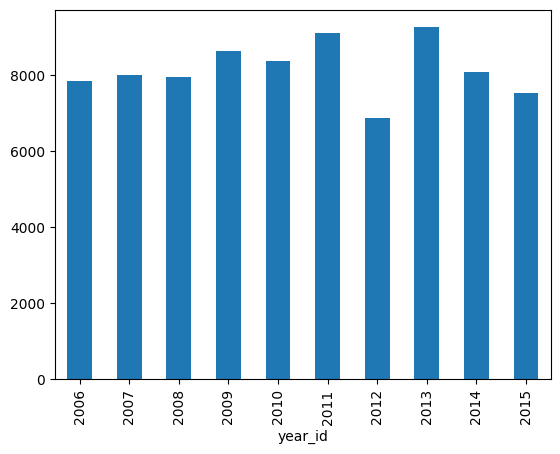

In [109]:
knicks_pts_by_year.tail(10).plot(kind = 'bar')
# knicks_pts_by_year.min()

In [122]:
my_df = pd.read_csv("nba_all_elo.csv")

my_df.loc[my_df["pts"] > 170].sort_values(by = ["pts"], ascending=False).to_csv("new_test_file.csv")

In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame(
    data = {
        "name" : ['Xavier', 'Ann', 'Jana', 'Mark'],
        'city' : ['Mexico City', 'Toronto', 'Prague', 'Santa Ana'],
        'age' : [41, 28, 33, 23],
        'py-score' : [88.0, 79.0, 81.0, 85.0]
    },
    index = [101, 102, 103, 104]
)

In [8]:
df.loc[[x for x in df.index if x % 2 == 0],['age','py-score']]

,age,py-score
102,28,79.0
104,23,85.0


In [18]:
df.loc[101,"name"]

'Xavier'

In [10]:
df.axes[0]

Index([101, 102, 103, 104], dtype='int64')

In [17]:
df.iloc[1,1]

'Toronto'

In [19]:
len(df)

4

In [31]:
[f"{score:.2f}" for score in df['py-score']]

['40.00', '56.67', '73.33', '90.00']

In [28]:
df['py-score']

101    40.000000
102    56.666667
103    73.333333
104    90.000000
Name: py-score, dtype: float64

In [38]:
new_scores = [float(f"{score:.2f}") for score in np.linspace(40,90, len(df))]
new_scores
df.iloc[:, -1] = new_scores

In [39]:
df

,name,city,age,py-score
101,Xavier,Mexico City,41,40.00
102,Ann,Toronto,28,56.67
103,Jana,Prague,33,73.33
104,Mark,Santa Ana,23,90.00


In [40]:
df.loc[105] = ['Tony', 'Los Angeles', 53, 88.0]

In [41]:
df

,name,city,age,py-score
101,Xavier,Mexico City,41,40.00
102,Ann,Toronto,28,56.67
103,Jana,Prague,33,73.33
104,Mark,Santa Ana,23,90.00
105,Tony,Los Angeles,53,88.00


In [43]:
df.at[103,'city'] = 'new Prague'

In [103]:
amy = pd.Series(
    data = ['Amy', 'Ottawa', 22, 92.00],
    index = df.columns,
    name = 106
)

In [39]:
df.loc[106] = series_a

In [60]:
df.iloc[5].Name = 106

In [ ]:
df.drop(labels = [106], inplace=True)

,name,city,age,py-score
101,Xavier,Mexico City,41,88.0
102,Ann,Toronto,28,79.0
103,Jana,Prague,33,81.0
104,Mark,Santa Ana,23,85.0
106,Amy,Ottawa,22,92.0


In [63]:
df.__dict__

{'_mgr': BlockManager
 Items: Index(['name', 'city', 'age', 'py-score'], dtype='str')
 Axis 1: Index([101, 102, 103, 104, 105, 5], dtype='int64')
 ExtensionBlock: slice(0, 1, 1), 1 x 6, dtype: str
 ExtensionBlock: slice(1, 2, 1), 1 x 6, dtype: str
 NumpyBlock: slice(2, 3, 1), 1 x 6, dtype: int64
 NumpyBlock: slice(3, 4, 1), 1 x 6, dtype: float64,
 '_attrs': {},
 '_flags': <Flags(allows_duplicate_labels=True)>}

In [ ]:
import numpy as np

In [69]:
a = np.array([[1,2],[3,4]])

In [76]:
a.__array_interface__['data'][0]

2143188972544

In [1]:
import numpy as np

In [65]:
np_a = np.array(
    [
    [[1,2,3],
    [4,5,6],
    [7,8,9]],
    [[0,2,3],
     [2,9,8],
     [9,6,5]]
    ]
)

In [9]:
a.shape

(2, 3, 3)

In [33]:
a[0,:,1]

array([2, 5, 8])

In [101]:
s_a = pd.Series(
    index = ['California', 'New York', 'Arizona'],
    data = [1000, 2000, 3000],
    name = 'US_States',
    dtype = np.float32
)

In [55]:
for value in s_a.values:
    print(value)

1000
2000
3000


In [56]:
for index in s_a.index:
    print(index)

California
New York
Arizona


In [57]:
for index in s_a:
    print(index)

1000
2000
3000


In [98]:
dict_a = {
    'a' : 'value1',
    'b' : 'value2',
    'c' : 'value3'
}



In [63]:
df

,name,city,age,py-score
101,Xavier,Mexico City,41,88.0
102,Ann,Toronto,28,79.0
103,Jana,Prague,33,81.0
104,Mark,Santa Ana,23,85.0
106,Amy,Ottawa,22,92.0


In [66]:
np_a

array([[[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]],

       [[0, 2, 3],
        [2, 9, 8],
        [9, 6, 5]]])

In [73]:
temp = np_a[0, 0]

temp[(temp > 1) | (temp <3)]

array([1, 2, 3])

In [ ]:
temp = np.array([1,1,2,3,4,4,5,6,7,7])

temp.not

1

In [89]:
df.info()

<class 'pandas.DataFrame'>
Index: 5 entries, 101 to 106
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      5 non-null      str    
 1   city      5 non-null      str    
 2   age       5 non-null      int64  
 3   py-score  5 non-null      float64
dtypes: float64(1), int64(1), str(2)
memory usage: 200.0 bytes


In [102]:
s_a

California    1000.0
New York      2000.0
Arizona       3000.0
Name: US_States, dtype: float32

In [121]:
amy = pd.Series(
    data = ['Amy', 'Ottawa', 22, 92.00],
    index = df.columns,
    name = 105
)

In [106]:
df.drop(labels = [106], inplace=True)

In [107]:
df

,name,city,age,py-score
101,Xavier,Mexico City,41,88.0
102,Ann,Toronto,28,79.0
103,Jana,Prague,33,81.0
104,Mark,Santa Ana,23,85.0


In [124]:
amy_df = amy.to_frame()
amy_df

,105
name,Amy
city,Ottawa
age,22
py-score,92.0


In [127]:
pd.concat([df, amy], axis = 1, join='inner')

,name,city,age,py-score,105


In [128]:
amy.to_numpy()

array(['Amy', 'Ottawa', 22, 92.0], dtype=object)

In [129]:
df.to_numpy()

array([['Xavier', 'Mexico City', 41, 88.0],
       ['Ann', 'Toronto', 28, 79.0],
       ['Jana', 'Prague', 33, 81.0],
       ['Mark', 'Santa Ana', 23, 85.0]], dtype=object)

In [138]:
np.vstack((df.to_numpy(), amy.to_numpy()))

array([['Xavier', 'Mexico City', 41, 88.0],
       ['Ann', 'Toronto', 28, 79.0],
       ['Jana', 'Prague', 33, 81.0],
       ['Mark', 'Santa Ana', 23, 85.0],
       ['Amy', 'Ottawa', 22, 92.0]], dtype=object)

In [137]:
import numpy as np

arr1 = np.array([[1, 2], [3, 4]])
arr2 = np.array([[5, 6], [7, 8]])
arr3 = np.array([9,10])

np.vstack((arr1, arr3))
# np.column_stack((arr1, arr3))

array([[ 1,  2],
       [ 3,  4],
       [ 9, 10]])

In [139]:
pd.DataFrame(data = np.vstack((df.to_numpy(), amy.to_numpy())),
             columns = df.columns
)

,name,city,age,py-score
0,Xavier,Mexico City,41,88.0
1,Ann,Toronto,28,79.0
2,Jana,Prague,33,81.0
3,Mark,Santa Ana,23,85.0
4,Amy,Ottawa,22,92.0


In [140]:
df

,name,city,age,py-score
101,Xavier,Mexico City,41,88.0
102,Ann,Toronto,28,79.0
103,Jana,Prague,33,81.0
104,Mark,Santa Ana,23,85.0


In [141]:
df['js-score'] = [45.0, 66.0, 78.0, 98.0]
df

,name,city,age,py-score,js-score
101,Xavier,Mexico City,41,88.0,45.0
102,Ann,Toronto,28,79.0,66.0
103,Jana,Prague,33,81.0,78.0
104,Mark,Santa Ana,23,85.0,98.0


In [142]:
df['total-score'] = 0.0

In [143]:
df

,name,city,age,py-score,js-score,total-score
101,Xavier,Mexico City,41,88.0,45.0,0.0
102,Ann,Toronto,28,79.0,66.0,0.0
103,Jana,Prague,33,81.0,78.0,0.0
104,Mark,Santa Ana,23,85.0,98.0,0.0


In [144]:
df.insert(loc = 4, column = 'django-score', value = [55.0, 77.0, 48.0, 88.0] )

In [145]:
df

,name,city,age,py-score,django-score,js-score,total-score
101,Xavier,Mexico City,41,88.0,55.0,45.0,0.0
102,Ann,Toronto,28,79.0,77.0,66.0,0.0
103,Jana,Prague,33,81.0,48.0,78.0,0.0
104,Mark,Santa Ana,23,85.0,88.0,98.0,0.0


In [2]:
new_col = pd.Series(
    index = df.index,
    data = [99.0, 66.0, 76.0, 87.0],
    name = 'dotnet-score'
)

In [3]:
new_col

101    99.0
102    66.0
103    76.0
104    87.0
Name: dotnet-score, dtype: float64

In [5]:
df = pd.concat((df, new_col), axis = 1, join = 'inner')

In [7]:
df.pop("dotnet-score")

101    99.0
102    66.0
103    76.0
104    87.0
Name: dotnet-score, dtype: float64

In [8]:
df

,name,city,age,py-score
101,Xavier,Mexico City,41,88.0
102,Ann,Toronto,28,79.0
103,Jana,Prague,33,81.0
104,Mark,Santa Ana,23,85.0


In [15]:
c = np.array([[[[1,2],[3,4]],[[5,6],[7,8]]], [[[1,2],[3,4]],[[5,6],[7,8]]]])
c

array([[[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]],


       [[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]]])

In [16]:
c.shape

(2, 2, 2, 2)

In [21]:
np.sum(c, axis = 3)

array([[[ 3,  7],
        [11, 15]],

       [[ 3,  7],
        [11, 15]]])

In [3]:
for index in df.index:
    for column in df.columns:
        print(df.loc[index, column])

Xavier
Mexico City
41
88.0
Ann
Toronto
28
79.0
Jana
Prague
33
81.0
Mark
Santa Ana
23
85.0


In [4]:
[df.loc[index, column] for index in df.index for column in df.columns]

['Xavier',
 'Mexico City',
 np.int64(41),
 np.float64(88.0),
 'Ann',
 'Toronto',
 np.int64(28),
 np.float64(79.0),
 'Jana',
 'Prague',
 np.int64(33),
 np.float64(81.0),
 'Mark',
 'Santa Ana',
 np.int64(23),
 np.float64(85.0)]

In [7]:
df.loc[102, 'py-score'] = 88.0

In [8]:
df

,name,city,age,py-score
101,Xavier,Mexico City,41,88.0
102,Ann,Toronto,28,88.0
103,Jana,Prague,33,81.0
104,Mark,Santa Ana,23,85.0


In [9]:
df.sort_values(by = ['py-score', 'age'], ascending=[False, True] )

,name,city,age,py-score
102,Ann,Toronto,28,88.0
101,Xavier,Mexico City,41,88.0
104,Mark,Santa Ana,23,85.0
103,Jana,Prague,33,81.0


In [10]:
df.sort_index()

,name,city,age,py-score
101,Xavier,Mexico City,41,88.0
102,Ann,Toronto,28,88.0
103,Jana,Prague,33,81.0
104,Mark,Santa Ana,23,85.0


In [14]:
df

,name,city,age,py-score
101,Xavier,Mexico City,41,88.0
102,Ann,Toronto,28,88.0
103,Jana,Prague,33,81.0
104,Mark,Santa Ana,23,85.0


In [12]:
df['py-score'].where(cond = df['age'] >= 25, other = 0.0)

101    88.0
102    88.0
103    81.0
104     0.0
Name: py-score, dtype: float64

In [20]:
df.filter(like = '4')

""
101
102
103
104


In [23]:
for col_label, values in df.iterrows():
    print(col_label)
    print(values)

101
name             Xavier
city        Mexico City
age                  41
py-score           88.0
Name: 101, dtype: object
102
name            Ann
city        Toronto
age              28
py-score       88.0
Name: 102, dtype: object
103
name          Jana
city        Prague
age             33
py-score      81.0
Name: 103, dtype: object
104
name             Mark
city        Santa Ana
age                23
py-score         85.0
Name: 104, dtype: object


In [24]:
temp_c = [ 8.0,  7.1,  6.8,  6.4,  6.0,  5.4,  4.8,  5.0,
           9.1, 12.8, 15.3, 19.1, 21.2, 22.1, 22.4, 23.1,
          21.0, 17.9, 15.5, 14.4, 11.9, 11.0, 10.2,  9.1]

In [26]:
dt_index = pd.date_range(start = '2026-02-20', freq = 'h', periods= 6)
dt_index

DatetimeIndex(['2026-02-20 00:00:00', '2026-02-20 01:00:00',
               '2026-02-20 02:00:00', '2026-02-20 03:00:00',
               '2026-02-20 04:00:00', '2026-02-20 05:00:00'],
              dtype='datetime64[us]', freq='h')

In [30]:
temp = pd.DataFrame(data = {'temp_c' : temp_c[0:6]},
             index = dt_index
                     )

In [31]:
temp

,temp_c
2026-02-20 00:00:00,8.0
2026-02-20 01:00:00,7.1
2026-02-20 02:00:00,6.8
2026-02-20 03:00:00,6.4
2026-02-20 04:00:00,6.0
2026-02-20 05:00:00,5.4


In [37]:
temp.loc['2026-02-20': '2026-02-20 04:00:00']

,temp_c
2026-02-20 00:00:00,8.0
2026-02-20 01:00:00,7.1
2026-02-20 02:00:00,6.8
2026-02-20 03:00:00,6.4
2026-02-20 04:00:00,6.0


In [ ]:
resample_obj = temp.resample(rule='2h')


KeyError: 'Column not found: slice(None, None, None)'

In [46]:
for key, sample in resample_obj:
    print(f"key:{key}")
    print(sample)
    print('\n')

resample_obj.mean()

key:2026-02-20 00:00:00
                     temp_c
2026-02-20 00:00:00     8.0
2026-02-20 01:00:00     7.1


key:2026-02-20 02:00:00
                     temp_c
2026-02-20 02:00:00     6.8
2026-02-20 03:00:00     6.4


key:2026-02-20 04:00:00
                     temp_c
2026-02-20 04:00:00     6.0
2026-02-20 05:00:00     5.4




,temp_c
2026-02-20 00:00:00,7.55
2026-02-20 02:00:00,6.60
2026-02-20 04:00:00,5.70


In [55]:
temp.rolling(window = 3, center=True).mean()

,temp_c
2026-02-20 00:00:00,NaN
2026-02-20 01:00:00,7.300000
2026-02-20 02:00:00,6.766667
2026-02-20 03:00:00,6.400000
2026-02-20 04:00:00,5.933333
2026-02-20 05:00:00,NaN


In [53]:
for data in rolling_obj:
    # print(name)
    print(data.mean())

temp_c    8.0
dtype: float64
temp_c    7.55
dtype: float64
temp_c    7.3
dtype: float64
temp_c    6.766667
dtype: float64
temp_c    6.4
dtype: float64
temp_c    5.933333
dtype: float64


In [56]:
import numpy as np

In [57]:
num_arr = np.arange(0,10)
num_arr

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [58]:
np.full((3,3), 5)

array([[5, 5, 5],
       [5, 5, 5],
       [5, 5, 5]])

In [59]:
np.eye(4)

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [60]:
np.linspace(1, 100,10)

array([  1.,  12.,  23.,  34.,  45.,  56.,  67.,  78.,  89., 100.])

In [61]:
np.random.rand(2,2)

array([[0.388889  , 0.54162118],
       [0.69540398, 0.70506251]])

In [8]:
import numpy as np

a = np.array([[1,2],
     [3,4],[5,6]])

np.sum(a)

np.int64(21)

In [9]:
a.argmax()

np.int64(5)

In [ ]:
np.bincount()